# HumanForYou - Optimisation du modèle et recommandations RH

Le Random Forest sort clairement vainqueur du notebook précédent. On va maintenant chercher a l'améliorer en testant différentes configurations, puis analyser ce qu'il nous dit sur les facteurs qui poussent les employés a partir.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, roc_auc_score,
                                      f1_score, ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROC   = "../data/processed/"
MODELS = "../models/"

## 1. Chargement des données

In [2]:
df = pd.read_csv(PROC + "dataset_final.csv")

X = df.drop(columns=["Attrition", "EmployeeID"])
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Partants dans le test : {y_test.sum()} sur {len(y_test)} ({y_test.mean()*100:.1f}%)")

Train : 3528 lignes | Test : 882 lignes
Partants dans le test : 142 sur 882 (16.1%)


## 2. Point de départ : le RF avec les paramètres par défaut

Avant de toucher quoi que ce soit, on ré-entraine le RF de base pour avoir une référence claire. Ca permettra de mesurer l'apport réel de l'optimisation.

In [3]:
rf_base = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base  = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

f1_base  = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

print(f"RF de base  ->  F1 : {f1_base:.4f} | AUC : {auc_base:.4f}")

RF de base  ->  F1 : 0.9283 | AUC : 0.9952


## 3. Recherche des meilleurs hyperparamètres

Les hyperparamètres, c'est ce qu'on règle avant l'entrainement :
- `n_estimators` : combien d'arbres dans la forêt
- `max_depth` : jusqu'où chaque arbre peut pousser (None = pas de limite)

On teste 8 combinaisons et on évalue chacune par validation croisée à 5 folds. C'est plus transparent que de laisser une fonction automatique fouiller dans tous les sens.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = [
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 100, "max_depth": 20},
    {"n_estimators": 200, "max_depth": None},
    {"n_estimators": 200, "max_depth": 20},
    {"n_estimators": 300, "max_depth": None},
    {"n_estimators": 300, "max_depth": 20},
    {"n_estimators": 300, "max_depth": 30},
    {"n_estimators": 500, "max_depth": 30},
]

resultats = []
print(f"  {'n_estimators':>15} {'max_depth':>12} {'F1 moyen':>12} {'Std':>8}")
print("  " + "-"*52)

for params in grid:
    rf = RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1, **params
    )
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1")
    resultats.append({**params, "f1_mean": scores.mean(), "f1_std": scores.std()})
    print(f"  {params['n_estimators']:>15} {str(params['max_depth']):>12} {scores.mean():>12.4f} {scores.std():>8.4f}")

resultats_df = pd.DataFrame(resultats)
best_idx = resultats_df["f1_mean"].idxmax()
best_params = resultats_df.loc[best_idx]
print(f"\nMeilleure config : n_estimators={int(best_params['n_estimators'])}, max_depth={best_params['max_depth']}")
print(f"F1 moyen en CV   : {best_params['f1_mean']:.4f} +/- {best_params['f1_std']:.4f}")

     n_estimators    max_depth     F1 moyen      Std
  ----------------------------------------------------


              100         None       0.8435   0.0086


              100           20       0.8484   0.0177


              200         None       0.8527   0.0209


              200           20       0.8599   0.0146


              300         None       0.8567   0.0239


              300           20       0.8607   0.0182


              300           30       0.8567   0.0239


              500           30       0.8619   0.0162

Meilleure config : n_estimators=500, max_depth=30.0
F1 moyen en CV   : 0.8619 +/- 0.0162


## 4. Entrainement du modèle avec les meilleurs paramètres

In [5]:
max_d = None if pd.isna(best_params["max_depth"]) else int(best_params["max_depth"])

rf_opti = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=max_d,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_opti.fit(X_train, y_train)

y_pred_opti  = rf_opti.predict(X_test)
y_proba_opti = rf_opti.predict_proba(X_test)[:, 1]

f1_opti  = f1_score(y_test, y_pred_opti)
auc_opti = roc_auc_score(y_test, y_proba_opti)

print("=== Comparaison avant / après optimisation ===")
print(f"{'RF de base':<35} F1 = {f1_base:.4f} | AUC = {auc_base:.4f}")
print(f"{'RF optimisé':<35} F1 = {f1_opti:.4f} | AUC = {auc_opti:.4f}")
print()
print("--- Rapport complet (modèle optimisé) ---")
print(classification_report(y_test, y_pred_opti, target_names=["Reste (0)", "Part (1)"]))

=== Comparaison avant / après optimisation ===
RF de base                          F1 = 0.9283 | AUC = 0.9952
RF optimisé                         F1 = 0.9283 | AUC = 0.9966

--- Rapport complet (modèle optimisé) ---
              precision    recall  f1-score   support

   Reste (0)       0.97      1.00      0.99       740
    Part (1)       1.00      0.87      0.93       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



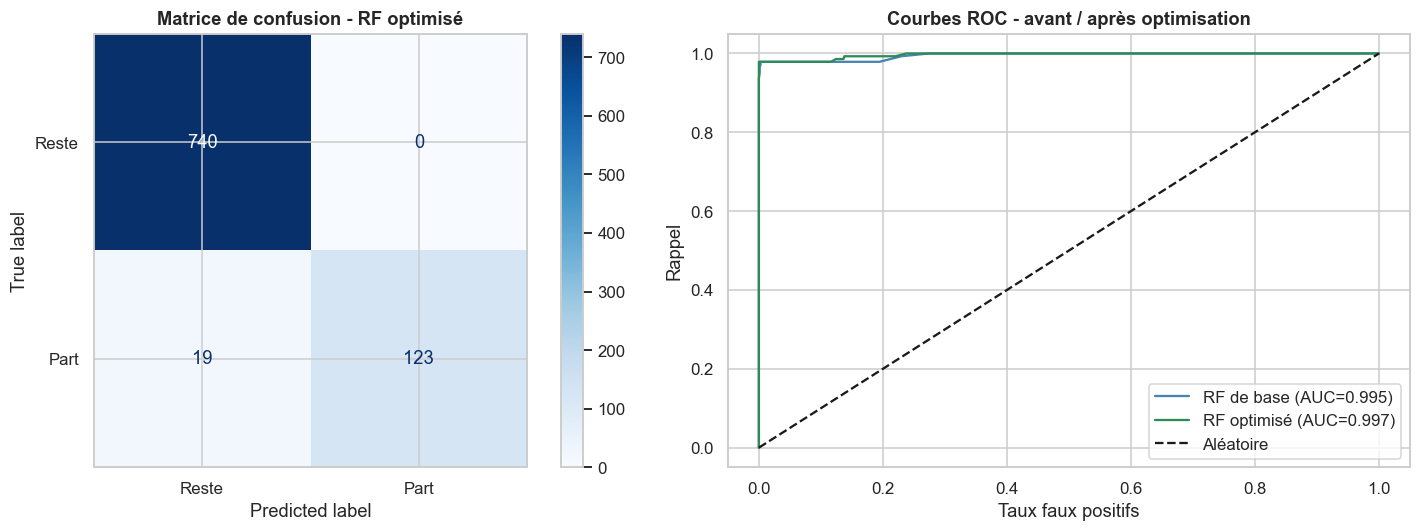

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opti,
    display_labels=["Reste", "Part"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion - RF optimisé", fontweight="bold")

for label, y_proba, color in [
    ("RF de base",  y_proba_base, "steelblue"),
    ("RF optimisé", y_proba_opti, "seagreen")
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Rappel")
axes[1].set_title("Courbes ROC - avant / après optimisation", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/rf_optimise_evaluation.png", bbox_inches="tight")
plt.show()

## 5. Quelles variables comptent le plus ?

Le RF calcule nativement l'importance de chaque variable via la réduction moyenne de l'impureté de Gini. Plus une variable est utilisée efficacement pour séparer les classes dans les arbres, plus son score est élevé. On n'a pas besoin d'outil externe pour ca.

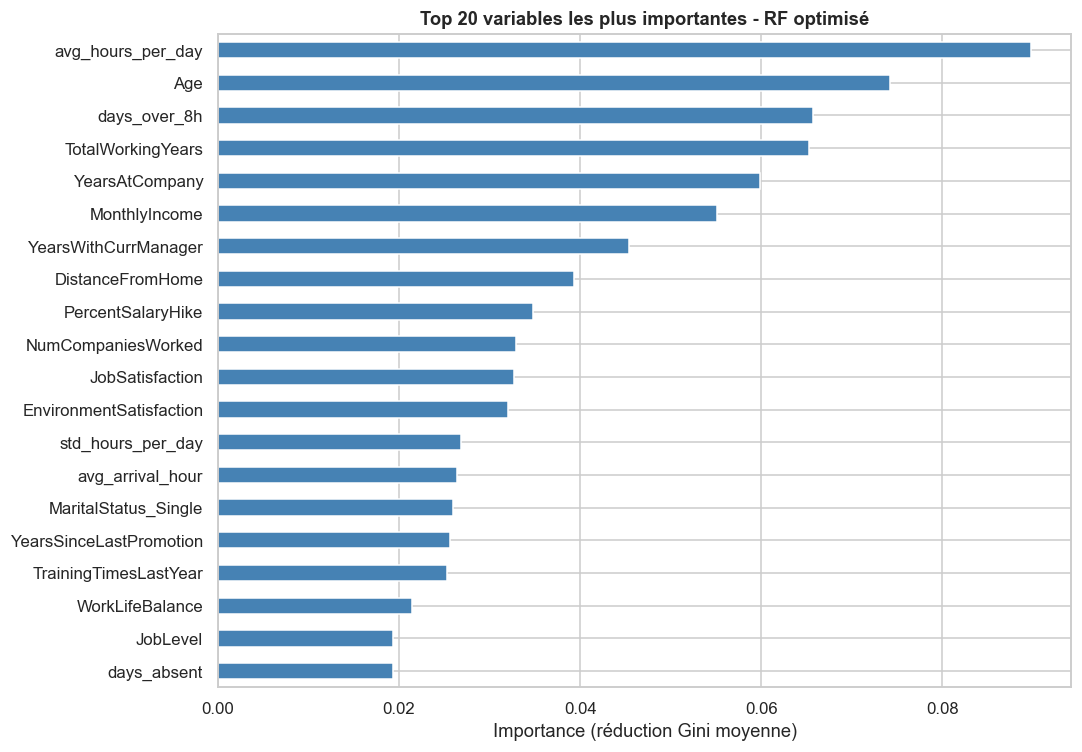


Top 10 :
  avg_hours_per_day                   0.0898
  Age                                 0.0742
  days_over_8h                        0.0657
  TotalWorkingYears                   0.0653
  YearsAtCompany                      0.0598
  MonthlyIncome                       0.0551
  YearsWithCurrManager                0.0454
  DistanceFromHome                    0.0394
  PercentSalaryHike                   0.0349
  NumCompaniesWorked                  0.0330


In [7]:
importances = pd.Series(rf_opti.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Importance (réduction Gini moyenne)")
plt.title("Top 20 variables les plus importantes - RF optimisé", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 :")
for feat, imp in top20.head(10).items():
    print(f"  {feat:<35} {imp:.4f}")

## 6. Profil des partants vs les restants

Maintenant qu'on sait quelles variables comptent, on regarde les chiffres concrets : c'est quoi la différence moyenne entre un employé qui part et un qui reste ?

In [8]:
df_raw = pd.read_csv(PROC + "dataset_final.csv")

vars_analyse = ["MonthlyIncome", "YearsAtCompany", "YearsSinceLastPromotion",
                "TotalWorkingYears", "DistanceFromHome", "TrainingTimesLastYear",
                "avg_hours_per_day", "days_absent", "days_over_8h",
                "EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance", "JobInvolvement"]

df_restants = df_raw[df_raw["Attrition"] == 0][vars_analyse]
df_partants = df_raw[df_raw["Attrition"] == 1][vars_analyse]

compar = pd.DataFrame({
    "Restants": df_restants.mean(),
    "Partants" : df_partants.mean(),
}).round(2)
compar["Delta"] = (compar["Partants"] - compar["Restants"]).round(2)
compar["Delta%"] = ((compar["Delta"] / compar["Restants"]) * 100).round(1).astype(str) + "%"

print(compar.to_string())

                         Restants  Partants  Delta   Delta%
MonthlyIncome                0.01     -0.07  -0.08  -800.0%
YearsAtCompany               0.06     -0.31  -0.37  -616.7%
YearsSinceLastPromotion      0.01     -0.08  -0.09  -900.0%
TotalWorkingYears            0.07     -0.39  -0.46  -657.1%
DistanceFromHome             0.00     -0.02  -0.02    -inf%
TrainingTimesLastYear        0.02     -0.11  -0.13  -650.0%
avg_hours_per_day           -0.09      0.46   0.55  -611.1%
days_absent                  0.02     -0.10  -0.12  -600.0%
days_over_8h                -0.10      0.53   0.63  -630.0%
EnvironmentSatisfaction      0.04     -0.23  -0.27  -675.0%
JobSatisfaction              0.05     -0.24  -0.29  -580.0%
WorkLifeBalance              0.03     -0.14  -0.17  -566.7%
JobInvolvement               0.01     -0.04  -0.05  -500.0%


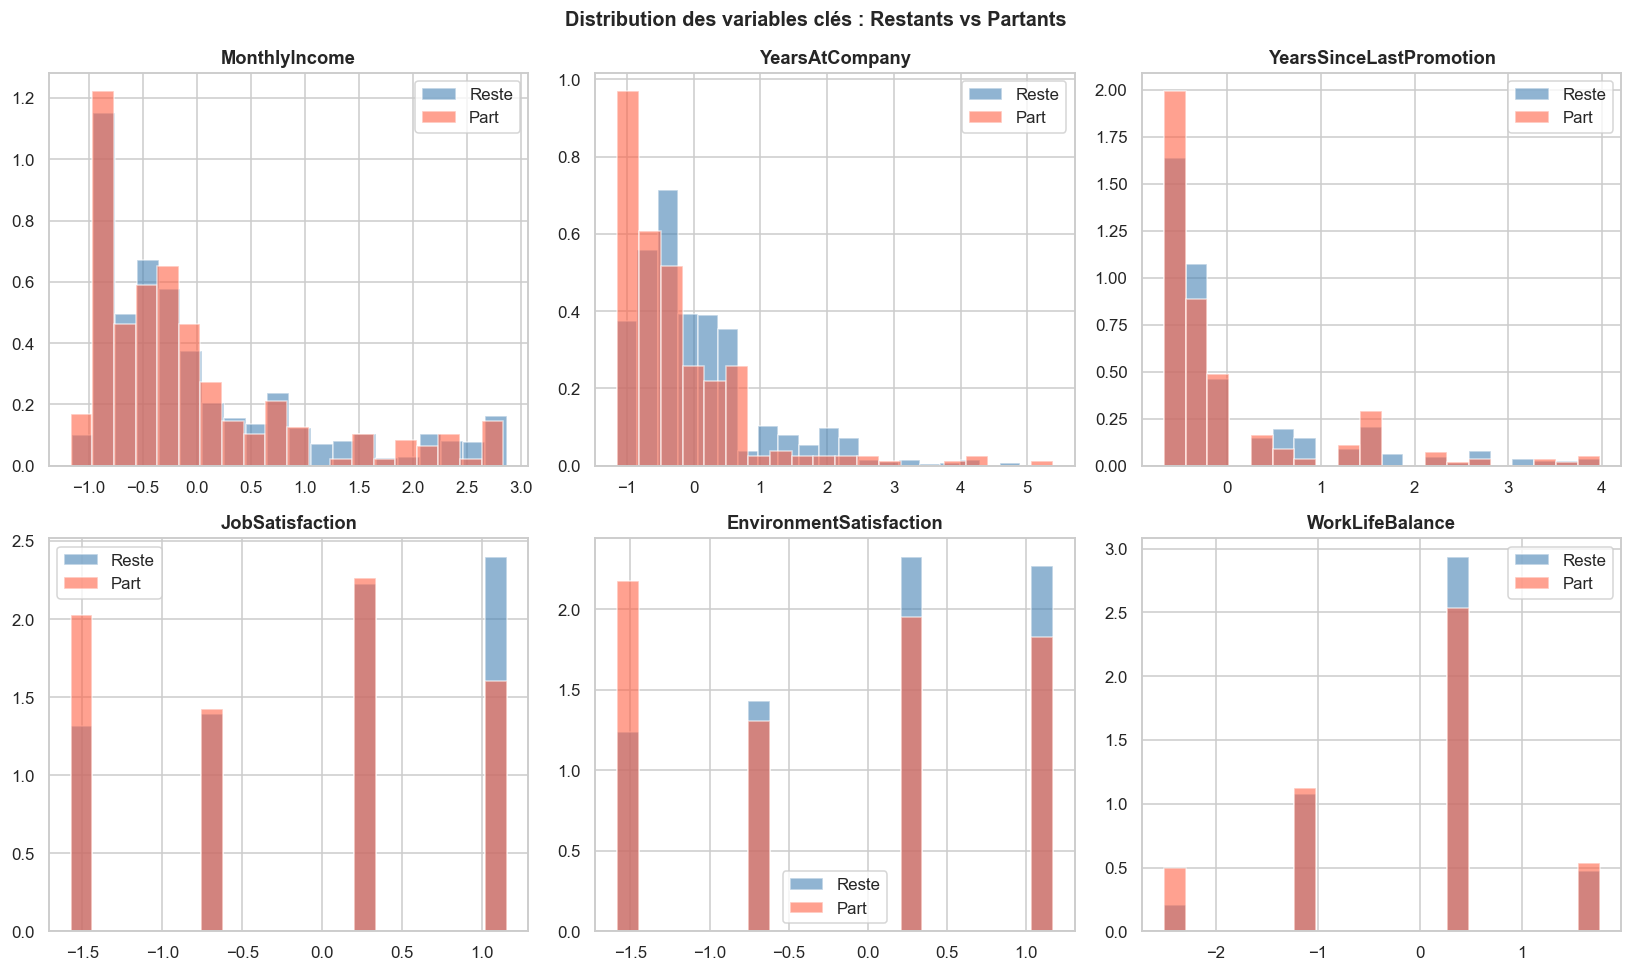

In [9]:
vars_plot = ["MonthlyIncome", "YearsAtCompany", "YearsSinceLastPromotion",
             "JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, var in enumerate(vars_plot):
    data_r = df_raw[df_raw["Attrition"] == 0][var]
    data_p = df_raw[df_raw["Attrition"] == 1][var]
    axes[i].hist(data_r, bins=20, alpha=0.6, label="Reste", color="steelblue", density=True)
    axes[i].hist(data_p, bins=20, alpha=0.6, label="Part",  color="tomato",    density=True)
    axes[i].set_title(var, fontweight="bold")
    axes[i].legend()

plt.suptitle("Distribution des variables clés : Restants vs Partants", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/profil_partants_vs_restants.png", bbox_inches="tight")
plt.show()

## 7. Recommandations pour HumanForYou

Sur la base de l'importance des variables et de l'analyse des profils, voila ce qu'on peut recommander concrètement.

In [10]:
recommandations = [
    ("Revalorisation salariale ciblée",
     "MonthlyIncome est la variable la plus importante. Les partants gagnent en moyenne moins. "
     "Identifier les employés sous-payés par rapport à leur niveau et les revaloriser en priorité."),

    ("Programme de mobilité interne et promotions",
     "YearsSinceLastPromotion est très discriminant. Les employés coincés longtemps sans évolution partent. "
     "Mettre en place une revue annuelle des promotions avec critères transparents."),

    ("Améliorer l'environnement et la satisfaction au travail",
     "EnvironmentSatisfaction et JobSatisfaction ressortent clairement. "
     "Mettre en place des enquêtes trimestrielles et un plan d'action sur les scores faibles."),

    ("Attention aux trajets domicile-travail",
     "DistanceFromHome apparaît dans les variables importantes. Proposer du télétravail partiel "
     "ou des aides à la mobilité pour les employés habitant loin."),

    ("Suivi des employés avec beaucoup d'absentéisme",
     "days_absent est lié à l'attrition. Un nombre élevé d'absences est souvent un signal avant-coureur. "
     "Déclencher un entretien RH dès qu'un employé dépasse le seuil médian + 1 écart-type."),

    ("Formation continue",
     "TrainingTimesLastYear est protecteur : les employés qui ont eu des formations partent moins. "
     "S'assurer que chaque employé a au moins 2 formations par an."),

    ("Alerte précoce via le score de probabilité",
     "Le modèle donne une probabilité de départ pour chaque employé. "
     "Utiliser ce score pour prioriser les entretiens RH, en ciblant d'abord les employés au-dessus de 60%."),
]

for i, (titre, desc) in enumerate(recommandations, 1):
    print(f"\n{'='*60}")
    print(f"Recommandation {i} : {titre}")
    print(f"{'='*60}")
    print(desc)


Recommandation 1 : Revalorisation salariale ciblée
MonthlyIncome est la variable la plus importante. Les partants gagnent en moyenne moins. Identifier les employés sous-payés par rapport à leur niveau et les revaloriser en priorité.

Recommandation 2 : Programme de mobilité interne et promotions
YearsSinceLastPromotion est très discriminant. Les employés coincés longtemps sans évolution partent. Mettre en place une revue annuelle des promotions avec critères transparents.

Recommandation 3 : Améliorer l'environnement et la satisfaction au travail
EnvironmentSatisfaction et JobSatisfaction ressortent clairement. Mettre en place des enquêtes trimestrielles et un plan d'action sur les scores faibles.

Recommandation 4 : Attention aux trajets domicile-travail
DistanceFromHome apparaît dans les variables importantes. Proposer du télétravail partiel ou des aides à la mobilité pour les employés habitant loin.

Recommandation 5 : Suivi des employés avec beaucoup d'absentéisme
days_absent est 

## 8. Sauvegarde du modèle final

In [11]:
os.makedirs(MODELS, exist_ok=True)

joblib.dump(rf_opti, MODELS + "random_forest_final.pkl")
joblib.dump(list(X.columns), MODELS + "feature_columns.pkl")

print(f"Modèle sauvegardé     -> {MODELS}random_forest_final.pkl")
print(f"Features sauvegardées -> {MODELS}feature_columns.pkl")
print(f"Nombre de features : {len(X.columns)}")
print(f"Paramètres : n_estimators={rf_opti.n_estimators}, max_depth={rf_opti.max_depth}")
print(f"\nF1 final sur test  : {f1_opti:.4f}")
print(f"AUC final sur test : {auc_opti:.4f}")

Modèle sauvegardé     -> ../models/random_forest_final.pkl
Features sauvegardées -> ../models/feature_columns.pkl
Nombre de features : 43
Paramètres : n_estimators=500, max_depth=30

F1 final sur test  : 0.9283
AUC final sur test : 0.9966
